# Bank Marketing Dataset

This notebook will follow the following process of exploratory data analysis for data preprocessing:

1. Initial data inspection
2. Data quality checks
3. Target variable analysis
4. Numerical feature analysis
5. Categorical feature analysis
6. Feature relationships with target
7. Preprocessing decisions

## Load and Inspect the Dataset

In [154]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt


# 2. Load the Dataset
DATA_PATH = "../data/bank-full.csv"
df = pd.read_csv(DATA_PATH, sep=";")

# 3.1 Inspect the dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [155]:
# 3.2 Inspect the first 5 rows
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


From `df.info()`, we can see that the dataset contains **45,211 entries** and **17 columns**. There are no null values to handle, which means there are no missing values represented as `NaN`.

However, several columns have the `object` data type. These columns represent categorical or binary variables and will need to be encoded before they can be used in a machine learning model. The target variable is the column labelled `y`, which indicates whether the client subscribed to a term deposit.

From `df.head(5)` and the variable descriptions, we can identify the following object-type columns:

### Binary categorical features

These columns contain two main categories, usually `yes` and `no`, making them straightforward to encode as `1` and `0`:

- `default` — whether the client has credit in default
- `housing` — whether the client has a housing loan
- `loan` — whether the client has a personal loan
- `y` — target variable: whether the client subscribed to a term deposit

### Ordinal categorical features

The `education` column can be treated as ordinal because the education levels have a natural order:

- `education` — education level of the client

Possible order:
unknown < primary < secondary < tertiary

However, the unknown category may need to be handled carefully because it does not represent a true education level.

### Nominal categorical features

These columns are categorical but do not have a natural order, so they should not be label-encoded as simple numbers. Instead, they are better suited for one-hot encoding:

job — type of occupation
marital — marital status
contact — contact communication type
month — month of last contact
poutcome — outcome of the previous marketing campaign
Numeric features

### Numerical Features

The remaining columns are numeric and can be used directly after checking their distributions and potential outliers:

age
balance
day
duration
campaign
pdays
previous

It is also important to note that duration may cause data leakage. The dataset description states that call duration is only known after the call has occurred. Since the goal is to build a realistic predictive model, this column may need to be removed before modelling.

## Data Quality Checks

In [156]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [157]:
df.duplicated().sum()

np.int64(0)

`df.isnull().sum()` confirms that there are no missing values in any of the columns.

In [158]:
def unknown_percentage(df):
    unknown_summary = pd.DataFrame({
        "unknown_count": (df == "unknown").sum(),
        "unknown_percentage": (df == "unknown").mean() * 100
    })

    unknown_summary = unknown_summary[unknown_summary["unknown_count"] > 0]
    unknown_summary.sort_values("unknown_percentage", ascending=False)
    return unknown_summary

unknown_percentage(df)

,unknown_count,unknown_percentage
job,288,0.637013
education,1857,4.107407
contact,13020,28.798301
poutcome,36959,81.747805


The `"unknown"` value check shows that missing or unavailable information is concentrated in a small number of categorical columns.

`poutcome` has the highest proportion of `"unknown"` values at approximately **81.5%**, which is expected because many clients were not contacted in a previous campaign. The `contact` column also has a high unknown rate at approximately **28.8%**.

The `education` and `job` columns contain much smaller proportions of `"unknown"` values, at approximately **4.1%** and **0.6%** respectively.

These values are not stored as `NaN`, so they need to be handled separately during preprocessing. For this project, `"unknown"` may be kept as its own category, especially for columns like `poutcome` and `contact`, where removing rows could result in significant data loss.

In [159]:
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
df[numeric_cols].describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


The numeric summary shows that several features contain wide ranges and potential outliers. `balance`, `duration`, `campaign`, `pdays`, and `previous` all have maximum values much higher than their upper quartiles, suggesting right-skewed distributions. 

The `pdays` column contains `-1`, which is not an error; it indicates that the client was not previously contacted. The `duration` column should be treated carefully because it may introduce data leakage if used in a realistic predictive model.

In [160]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(df[col].value_counts())
    print("\n")

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


default
no     44396
yes      815
Name: count, dtype: int64


housing
yes    25130
no     20081
Name: count, dtype: int64


loan
no     37967
yes     7244
Name: count, dtype: int64


contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


poutcome
unknown    36959
failure 

The categorical value counts show that several features are imbalanced across their categories. For example, `default` is heavily dominated by `no`, while the target variable `y` is also imbalanced, with far more clients not subscribing than subscribing.

Some columns also contain `"unknown"` values, especially `poutcome`, `contact`, `education`, and `job`. These values should be considered during preprocessing, either by keeping them as a separate category or handling them differently depending on the modelling approach.

Most categorical columns, such as `job`, `marital`, `contact`, `month`, and `poutcome`, are nominal and should be one-hot encoded. Binary columns such as `default`, `housing`, `loan`, and `y` can be encoded as `0` and `1`.

## Target Variable Analysis

In [161]:
df["y"].value_counts()
df["y"].value_counts(normalize=True) * 100

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

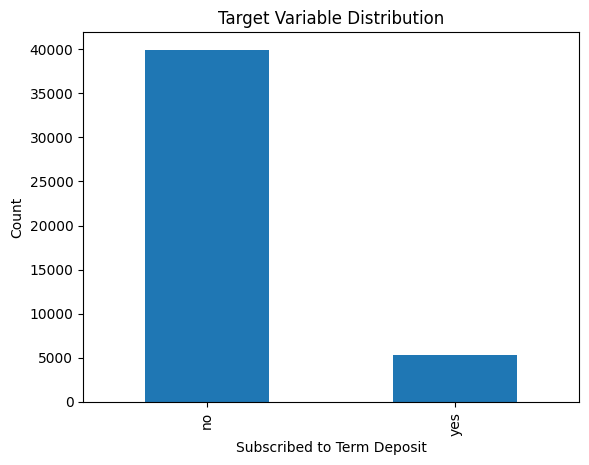

In [162]:
df["y"].value_counts().plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Count")
plt.show()

The target variable `y` indicates whether the client subscribed to a term deposit or not.

The dataset is imbalanced, with a much larger number of clients in the `no` class compared to the `yes` class. This means that accuracy alone may not be a reliable evaluation metric, because a model could achieve high accuracy by mostly predicting the majority class. At this stage, data scientists would go back and find/collect more data.

Because of this imbalance, additional classification metrics such as precision, recall, F1-score and a confusion matrix should be used when evaluating the model.

## Numerical Feature Analysis


In [163]:
numeric_cols = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]
df[numeric_cols].describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


The numeric summary shows that several features contain wide ranges and potential outliers. `balance`, `duration`, `campaign`, `pdays`, and `previous` all have maximum values much higher than their upper quartiles, suggesting right-skewed distributions.

The `pdays` column contains `-1`, which is not an error; it indicates that the client was not previously contacted. The `duration` column should be treated carefully because it may introduce data leakage if used in a realistic predictive model.

In [164]:
import matplotlib.pyplot as plt

def analyse_numeric_feature(df, col, target_col="y"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Histogram
    axes[0].hist(df[col], bins=30)
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    # Boxplot
    axes[1].boxplot(df[col])
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_ylabel(col)

    # Boxplot by target
    target_order = ["no", "yes"]
    groups = [df[df[target_col] == target][col] for target in target_order]

    axes[2].boxplot(groups, labels=target_order)
    axes[2].set_title(f"{col} by Subscription Outcome")
    axes[2].set_xlabel("Subscribed to Term Deposit")
    axes[2].set_ylabel(col)

    plt.tight_layout()
    plt.show()

This helper function is used to analyse one numeric feature at a time.

For each selected column, it creates three plots:

1. **Histogram**  
   Shows the distribution of the feature and helps identify whether the values are normally distributed, skewed, or concentrated in certain ranges.

2. **Boxplot**  
   Shows the median, spread, quartiles, and potential outliers for the feature.

3. **Boxplot grouped by target variable**  
   Compares the feature values for clients who subscribed to a term deposit (`yes`) and clients who did not subscribe (`no`). This helps identify whether the feature may be useful for predicting the target variable.

The function makes the numerical feature analysis more consistent by applying the same visual checks to each numeric column.

### Age

/var/folders/4q/ltzhp80j2l778lj9b6y5gqhm0000gn/T/ipykernel_26559/3896111404.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(groups, labels=target_order)


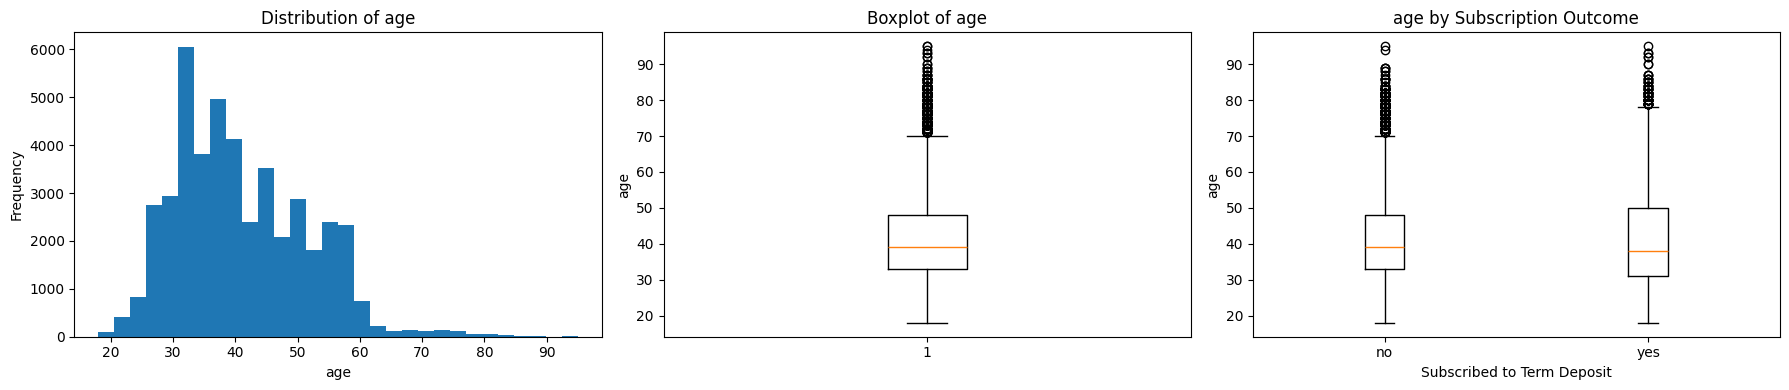

In [165]:
analyse_numeric_feature(df, "age")


The `age` distribution shows that most clients are between their late 20s and late 50s, with the highest concentration around the 30–40 age range.

The boxplot shows several older clients appearing as outliers, mostly above approximately 70 years old. These values are still realistic ages, so they should not automatically be treated as errors.

When comparing age against the target variable, the distributions for clients who subscribed and did not subscribe are fairly similar. However, the `yes` group appears to have a slightly wider age range, suggesting that age may provide some useful information, but is unlikely to be a strong predictor on its own.

### Balance

/var/folders/4q/ltzhp80j2l778lj9b6y5gqhm0000gn/T/ipykernel_26559/3896111404.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(groups, labels=target_order)


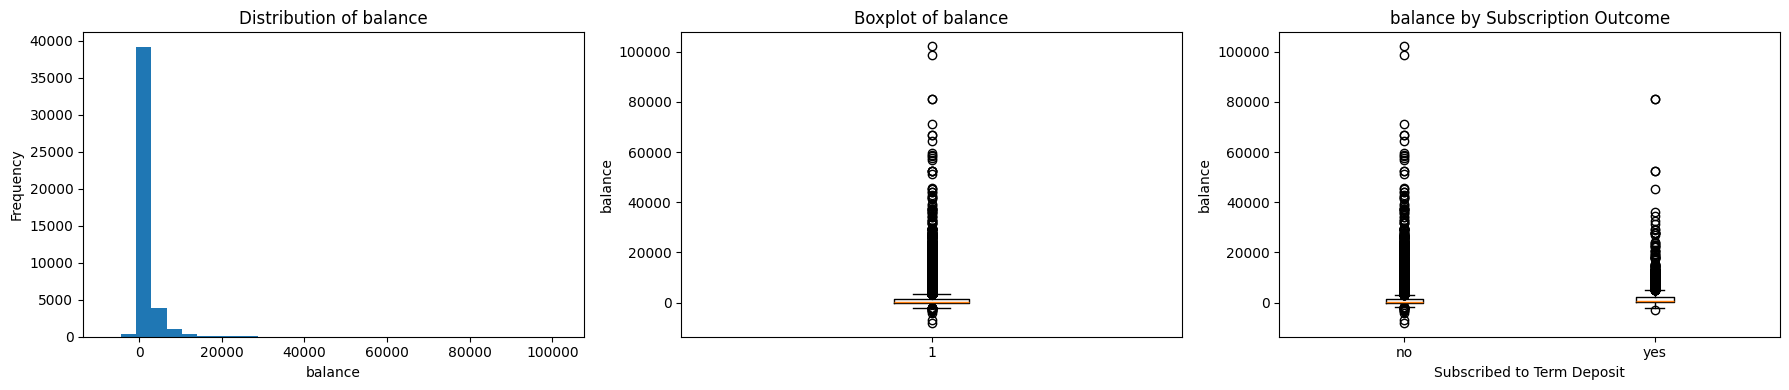

In [166]:
analyse_numeric_feature(df, "balance")

The `balance` feature is strongly right-skewed. Most clients have relatively low account balances, while a small number of clients have very large positive balances.

The boxplot shows many outliers, including both very high positive balances and some negative balances. These values may still be valid because account balances can vary widely and may be negative for some clients.

When comparing balance against the target variable, both the `yes` and `no` groups show similar distributions with many outliers. However, the `yes` group appears to have a slightly higher median balance, suggesting that balance may contain some useful predictive information, but it is unlikely to be strong enough on its own.

Because of the wide range and outliers, this feature should likely be scaled before being used in logistic regression.

### Day

/var/folders/4q/ltzhp80j2l778lj9b6y5gqhm0000gn/T/ipykernel_26559/3896111404.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(groups, labels=target_order)


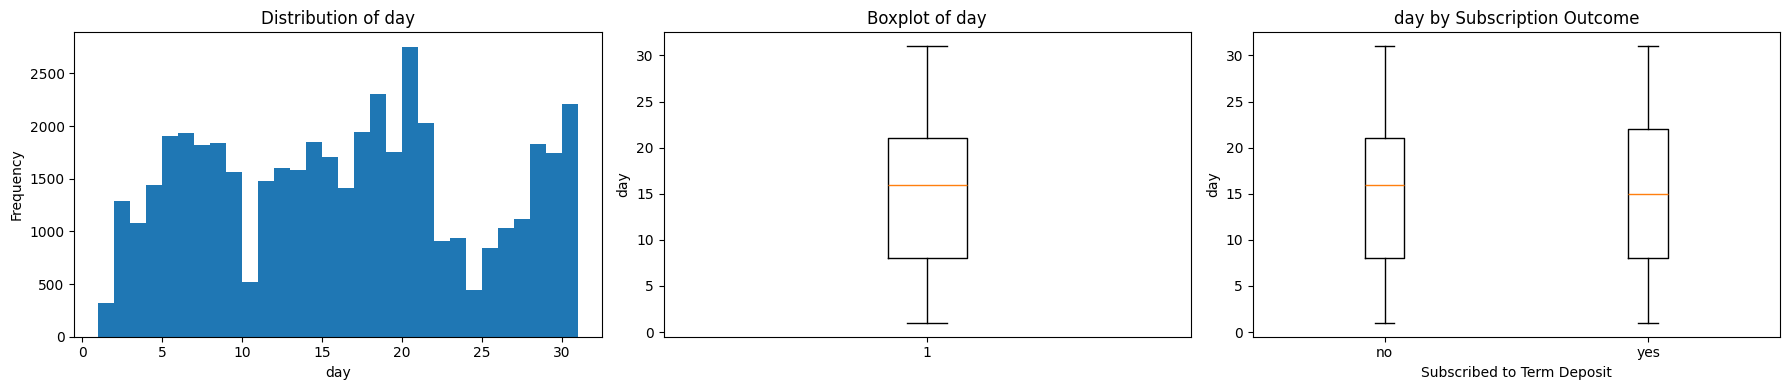

In [167]:
analyse_numeric_feature(df, "day")

The `day` feature represents the day of the month when the client was last contacted. The values are naturally bounded between 1 and 31, so this feature does not contain extreme outliers in the same way as variables like `balance` or `duration`.

The histogram shows that contacts were spread across the month, with some days having higher contact volumes than others. The boxplot confirms that the values cover most of the monthly range.

When comparing `day` against the target variable, the `yes` and `no` groups have very similar distributions. This suggests that the day of the month alone is unlikely to be a strong predictor of whether a client subscribed to a term deposit.

### Duration

/var/folders/4q/ltzhp80j2l778lj9b6y5gqhm0000gn/T/ipykernel_26559/3896111404.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(groups, labels=target_order)


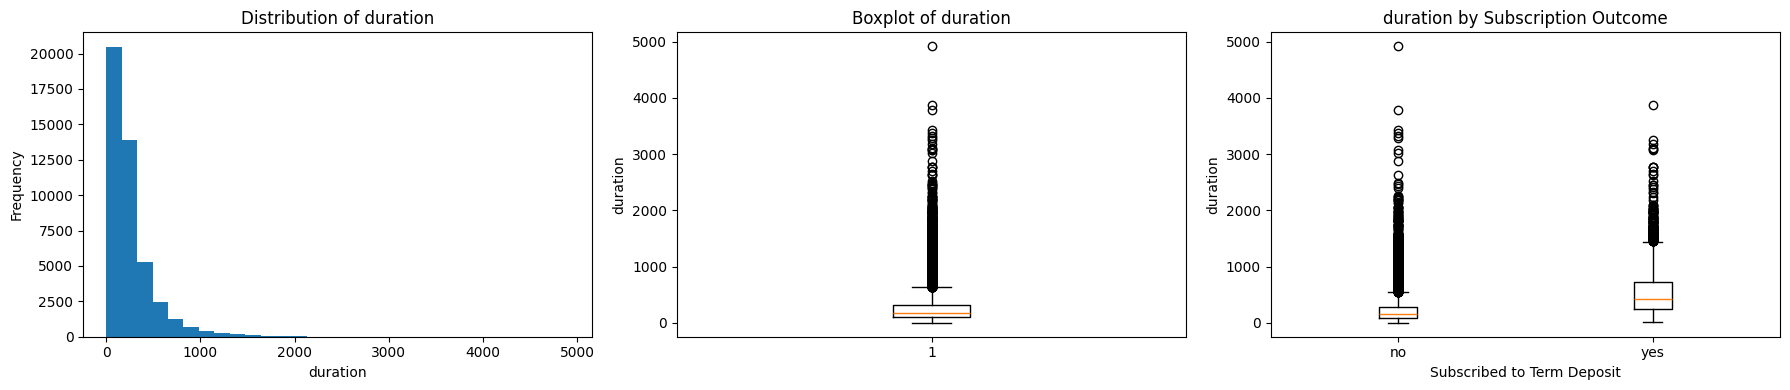

In [168]:
analyse_numeric_feature(df, "duration")

The `duration` feature is strongly right-skewed. Most calls are relatively short, while a smaller number of calls have much longer durations.

The boxplot shows many high-duration outliers, with some calls lasting several thousand seconds. These values may be valid, but they create a very wide range in the feature.

When comparing `duration` against the target variable, clients who subscribed (`yes`) generally appear to have longer call durations than clients who did not subscribe (`no`). This suggests that `duration` is strongly related to the target outcome.

However, this feature should be treated carefully because call duration is only known after the call has occurred. If the goal is to build a realistic model that predicts subscription before or during campaign planning, `duration` may introduce data leakage and should likely be removed before training the final model.

### pdays

/var/folders/4q/ltzhp80j2l778lj9b6y5gqhm0000gn/T/ipykernel_26559/3896111404.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(groups, labels=target_order)


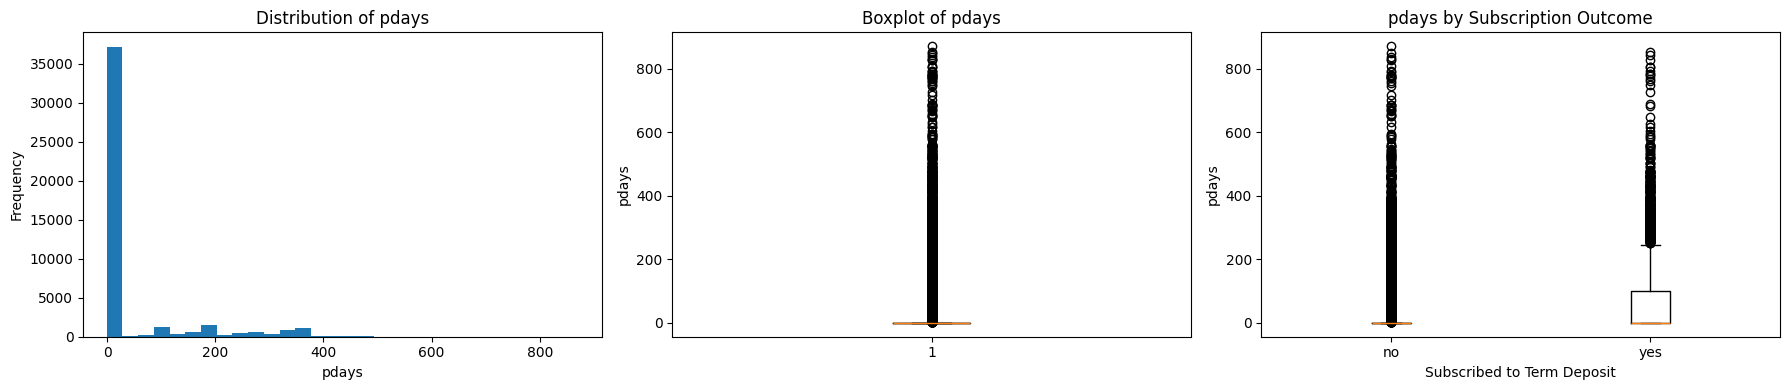

In [169]:
analyse_numeric_feature(df, "pdays")

The `pdays` feature is highly concentrated around `-1`, which indicates that the client was not previously contacted. This explains the large spike near the lower end of the distribution.

The boxplot shows many high values as outliers, representing clients who were contacted a long time after a previous campaign. These values are not necessarily errors, but they show that the feature is strongly skewed.

When comparing `pdays` against the target variable, the `yes` group appears to have a wider spread and higher values than the `no` group. This suggests that previous campaign contact history may contain useful predictive information.

Because `-1` has a special meaning, this feature should be handled carefully during preprocessing rather than treated as a normal numeric value.

### Previous

/var/folders/4q/ltzhp80j2l778lj9b6y5gqhm0000gn/T/ipykernel_26559/3896111404.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(groups, labels=target_order)


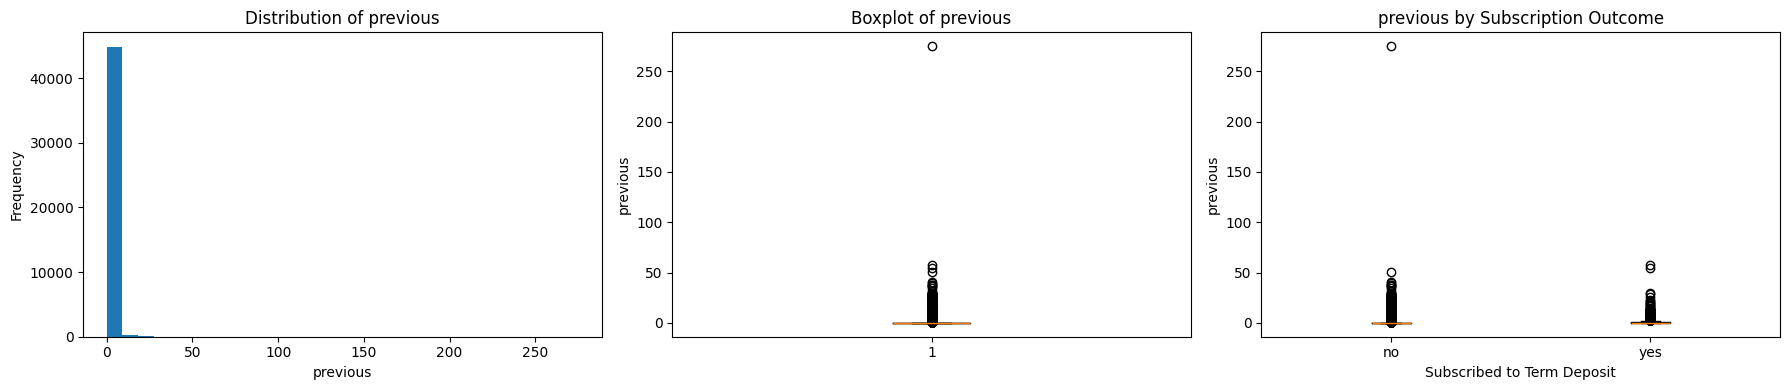

In [170]:
analyse_numeric_feature(df, "previous")


The `previous` feature represents the number of times a client was contacted before the current campaign.

The distribution is extremely right-skewed, with most clients having `0` previous contacts. This suggests that the majority of clients had not been contacted before this campaign.

The boxplot shows many outliers, including a very large maximum value. These values may represent clients who were contacted many times in previous campaigns, but they are uncommon compared to the rest of the dataset.

When comparing `previous` against the target variable, both the `yes` and `no` groups are heavily concentrated near `0`. However, the `yes` group appears to have slightly more spread, suggesting that previous contact history may contain some useful predictive information.

Because this feature is highly skewed and contains extreme values, it should likely be scaled before being used in logistic regression.

In [171]:
df.groupby("y")[numeric_cols].agg(["mean", "median"])

age             balance               day           duration  \
          mean median         mean median       mean median        mean   
y                                                                         
no   40.838986   39.0  1303.714969  417.0  15.892290   16.0  221.182806   
yes  41.670070   38.0  1804.267915  733.0  15.158253   15.0  537.294574   

            campaign             pdays         previous         
    median      mean median       mean median      mean median  
y                                                               
no   164.0  2.846350    2.0  36.421372   -1.0  0.502154    0.0  
yes  426.0  2.141047    2.0  68.702968   -1.0  1.170354    0.0

The grouped summary statistics show some differences between clients who subscribed (`yes`) and those who did not (`no`).

Clients who subscribed had a higher median `balance` and much longer call `duration` compared to clients who did not subscribe. The `yes` group also had a higher average value for `pdays` and `previous`, suggesting that previous campaign contact history may be related to subscription outcomes.

The `campaign` feature shows that clients who subscribed were contacted fewer times on average during the current campaign. This may suggest that repeated contact attempts do not necessarily lead to a higher subscription rate.

The median values for `pdays` and `previous` are the same across both groups, which shows that many clients had no previous campaign contact. Overall, `duration`, `balance`, `campaign`, `pdays`, and `previous` appear to be the most useful numeric features to investigate further.

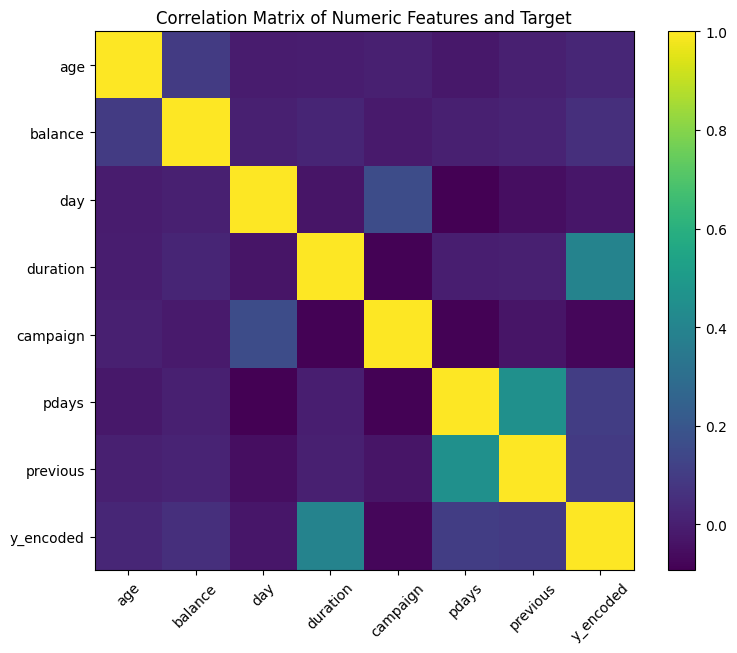

In [172]:
# Create a numeric version of the target variable
df["y_encoded"] = df["y"].map({"no": 0, "yes": 1})

# Add target variable to correlation columns
corr_cols = numeric_cols + ["y_encoded"]

corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix of Numeric Features and Target")
plt.show()

The correlation matrix shows the relationships between the numeric features and the encoded target variable, where `0 = no` and `1 = yes`.

Most numeric features have weak correlations with the target, suggesting that no single numeric feature strongly predicts subscription on its own. The strongest visible relationship is between `duration` and `y_encoded`, meaning longer call durations are associated with a higher chance of subscription.

There is also a noticeable relationship between `pdays` and `previous`, which makes sense because both features relate to previous campaign contact history.

Overall, the numeric features do not show major multicollinearity, but `duration` should still be treated carefully because it may introduce data leakage.

### Conclusion

The numerical feature analysis showed that several features are right-skewed and contain potential outliers, especially `balance`, `duration`, `campaign`, `pdays`, and `previous`. These values may still be valid, but they should be considered during preprocessing.

Some numeric features showed differences between clients who subscribed and those who did not. In particular, `duration`, `balance`, `pdays`, and `previous` appear to contain useful predictive information. However, `duration` should be treated carefully because it may introduce data leakage, as call duration is only known after the call has occurred.

The correlation matrix showed mostly weak relationships between the numeric features, meaning there is no major multicollinearity issue among them. Overall, the numeric features should likely be scaled before training the logistic regression model.


## Categorical Feature Analysis

In [173]:
categorical_cols = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

This section explores the categorical features in the dataset. For each feature, the category distribution and subscription rate are analysed to understand whether certain groups are more likely to subscribe to a term deposit. With the use of the following help function `analyse_categorical_feature()`

In [174]:
def analyse_categorical_feature(df, col, target_col="y"):
    print(f"Value counts for {col}:")
    display(df[col].value_counts())

    print(f"\nSubscription rate by {col}:")
    subscription_rate = (
        df.groupby(col)[target_col]
        .apply(lambda x: (x == "yes").mean() * 100)
        .sort_values(ascending=False)
    )

    display(subscription_rate)

    plt.figure(figsize=(10, 4))
    subscription_rate.plot(kind="bar")
    plt.title(f"Subscription Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Subscription Rate (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Value counts for job:


job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


Subscription rate by job:


job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: y, dtype: float64

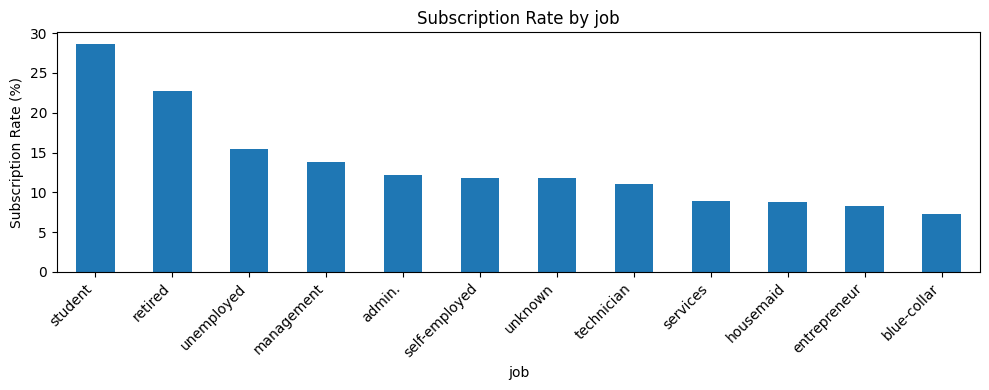

In [175]:
analyse_categorical_feature(df, "job")

Value counts for marital:


marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


Subscription rate by marital:


marital
single      14.949179
divorced    11.945458
married     10.123466
Name: y, dtype: float64

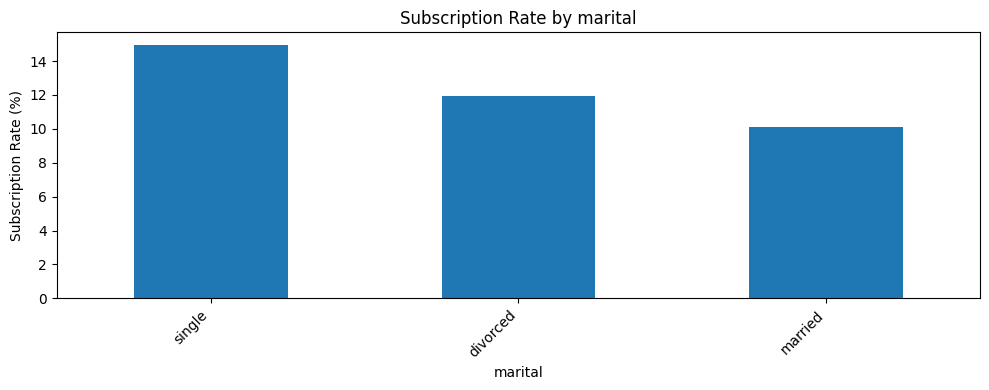

In [176]:
analyse_categorical_feature(df, "marital")

Value counts for education:


education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


Subscription rate by education:


education
tertiary     15.006390
unknown      13.570275
secondary    10.559435
primary       8.626478
Name: y, dtype: float64

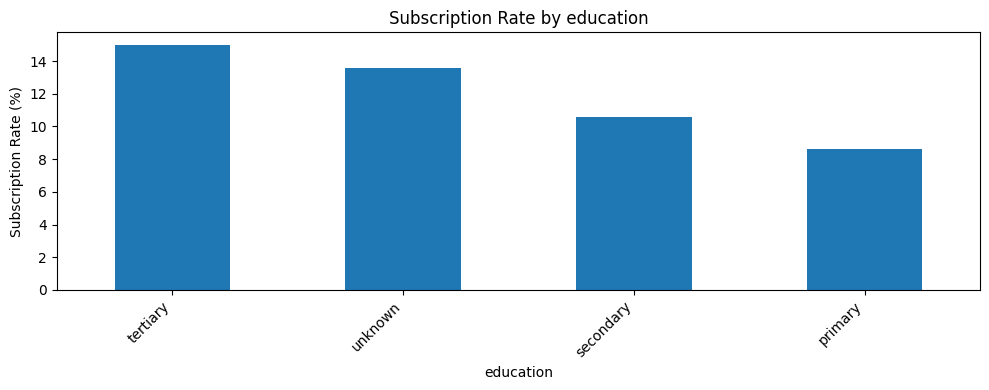

In [177]:
analyse_categorical_feature(df, "education")

Value counts for default:


default
no     44396
yes      815
Name: count, dtype: int64


Subscription rate by default:


default
no     11.796108
yes     6.380368
Name: y, dtype: float64

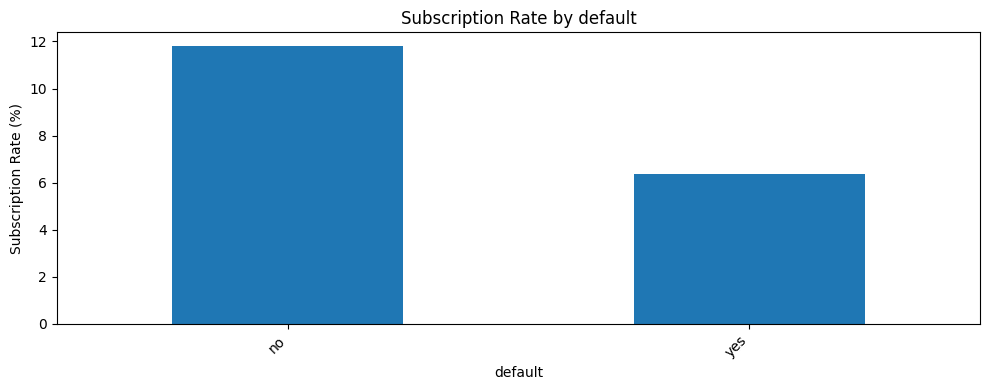

In [178]:
analyse_categorical_feature(df, "default")

Value counts for housing:


housing
yes    25130
no     20081
Name: count, dtype: int64


Subscription rate by housing:


housing
no     16.702355
yes     7.699960
Name: y, dtype: float64

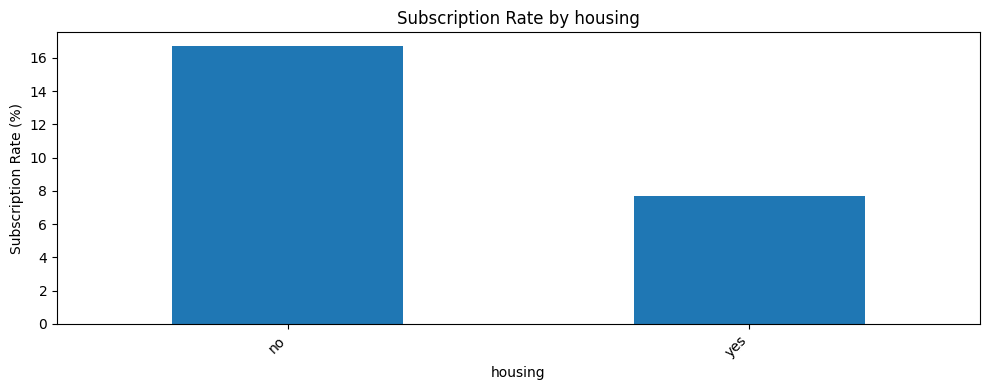

In [179]:
analyse_categorical_feature(df, "housing")

Value counts for loan:


loan
no     37967
yes     7244
Name: count, dtype: int64


Subscription rate by loan:


loan
no     12.655727
yes     6.681391
Name: y, dtype: float64

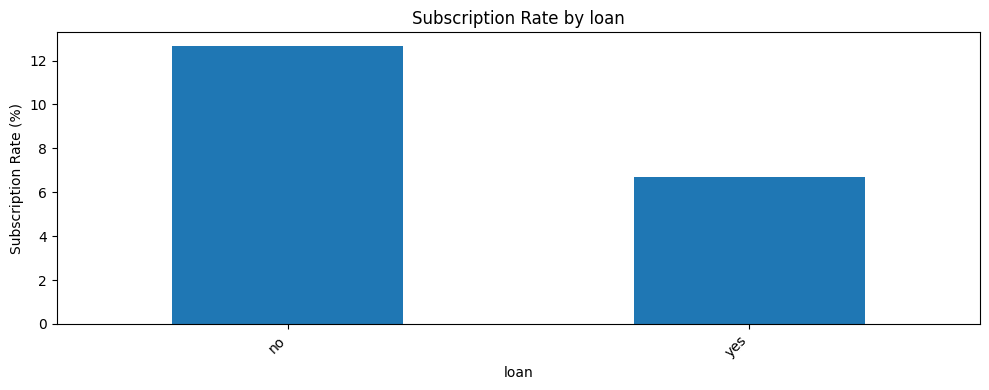

In [180]:
analyse_categorical_feature(df, "loan")

Value counts for contact:


contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


Subscription rate by contact:


contact
cellular     14.918900
telephone    13.420509
unknown       4.070661
Name: y, dtype: float64

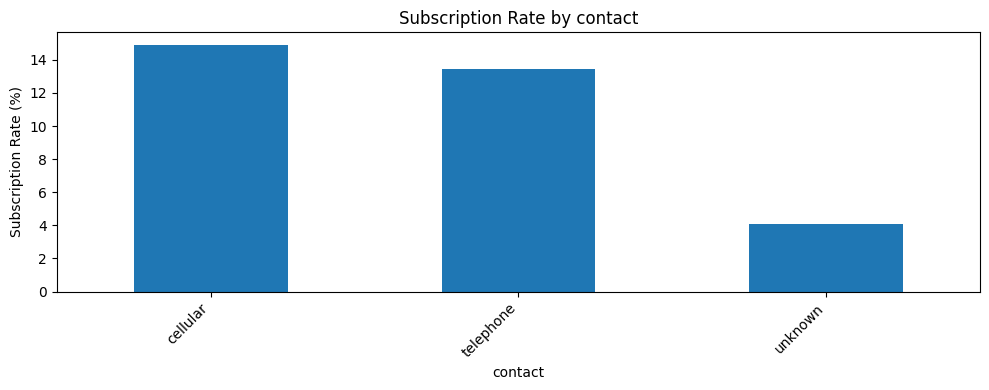

In [181]:
analyse_categorical_feature(df, "contact")

Value counts for month:


month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


Subscription rate by month:


month
mar    51.991614
dec    46.728972
sep    46.459413
oct    43.766938
apr    19.679400
feb    16.647792
aug    11.013286
jun    10.222805
nov    10.151134
jan    10.121169
jul     9.093546
may     6.719454
Name: y, dtype: float64

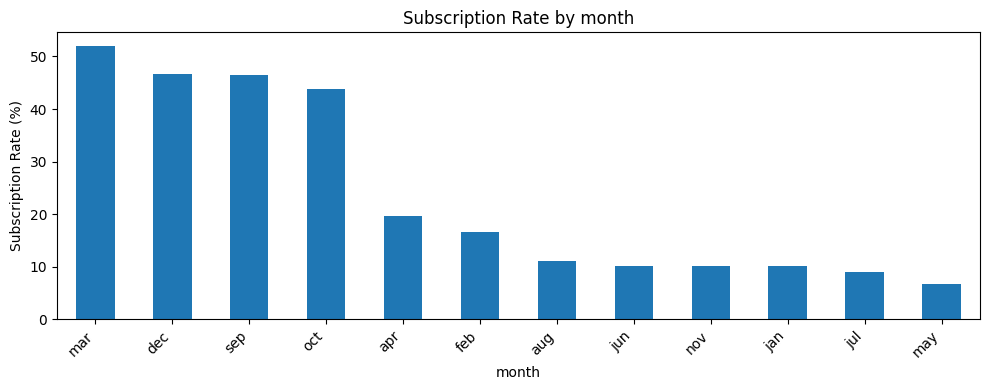

In [182]:
analyse_categorical_feature(df, "month")

Value counts for poutcome:


poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


Subscription rate by poutcome:


poutcome
success    64.725347
other      16.684783
failure    12.609671
unknown     9.161503
Name: y, dtype: float64

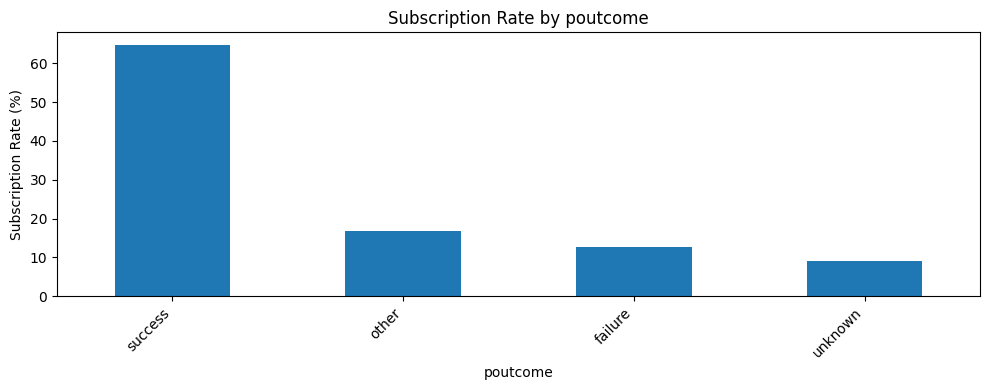

In [183]:
analyse_categorical_feature(df, "poutcome")

### Conclusion

The categorical feature analysis shows that several categorical variables have clear differences in subscription rates across their categories. Features such as `job`, `education`, `housing`, `loan`, `contact`, `month`, and `poutcome` appear to contain useful predictive information.

Some of the strongest differences are seen in `poutcome` and `month`. Clients with a previous campaign outcome of `success` had a much higher subscription rate than other groups, while some months such as `mar`, `dec`, `sep`, and `oct` showed noticeably higher subscription rates than months like `may` and `jul`. The `job` feature also showed variation, with students and retired clients having higher subscription rates than groups such as blue-collar and entrepreneur clients.

Several categorical features are imbalanced, and some contain `"unknown"` values, especially `poutcome` and `contact`. These values should be handled carefully during preprocessing rather than automatically removed, because removing them could result in significant data loss.

Most categorical features are nominal and should be one-hot encoded before modelling. Binary features such as `default`, `housing`, and `loan` can be encoded as `0` and `1`.

## Feature Relationship with Target

In [184]:
df.groupby("y")[numeric_cols].agg(["mean", "median"])

age             balance               day           duration  \
          mean median         mean median       mean median        mean   
y                                                                         
no   40.838986   39.0  1303.714969  417.0  15.892290   16.0  221.182806   
yes  41.670070   38.0  1804.267915  733.0  15.158253   15.0  537.294574   

            campaign             pdays         previous         
    median      mean median       mean median      mean median  
y                                                               
no   164.0  2.846350    2.0  36.421372   -1.0  0.502154    0.0  
yes  426.0  2.141047    2.0  68.702968   -1.0  1.170354    0.0

### Numerical Features and Target

The numerical features show some differences between clients who subscribed and those who did not.

Clients who subscribed generally had a higher median `balance`, longer call `duration`, and higher average values for `pdays` and `previous`. The `campaign` feature showed the opposite pattern, where clients who subscribed were contacted fewer times on average during the current campaign.

This suggests that `balance`, `campaign`, `pdays`, and `previous` may contain useful predictive information. However, `duration` should be treated carefully because it may introduce data leakage.

### Categorical Features and Target

Several categorical features show clear differences in subscription rates.

The strongest relationship appears in `poutcome`, where clients with a previous campaign outcome of `success` had a much higher subscription rate than other groups. The `month` feature also showed large differences, with months such as `mar`, `dec`, `sep`, and `oct` having much higher subscription rates than months such as `may` and `jul`.

Other features such as `job`, `education`, `housing`, `loan`, and `contact` also showed meaningful differences in subscription rates. For example, students and retired clients had higher subscription rates than blue-collar and entrepreneur clients, while clients without housing or personal loans were more likely to subscribe.

### Modelling Implications

The feature relationship analysis suggests that both numerical and categorical variables may be useful for predicting term deposit subscription.

Categorical variables should be encoded before modelling. Nominal features such as `job`, `marital`, `contact`, `month`, and `poutcome` should be one-hot encoded, while binary features such as `default`, `housing`, and `loan` can be encoded as `0` and `1`.

Numerical features should likely be scaled before training the logistic regression model because several of them have wide ranges and outliers.

The `duration` feature appears strongly related to the target, but because it is only known after the phone call has occurred, it may cause data leakage. For a realistic predictive model, this feature should likely be removed before training.

## Preprocessing Decisions

Based on the exploratory data analysis, the following preprocessing steps will be applied before training the logistic regression model.

### 1. Target Encoding

The target variable `y` contains two categories: `yes` and `no`.

These will be encoded as:

- `yes = 1`
- `no = 0`

This allows the target variable to be used in a binary classification model.

### 2. Handling Categorical Features

The dataset contains several categorical features that need to be converted into numeric form before modelling.

Binary categorical features such as `default`, `housing`, and `loan` can be encoded as `0` and `1`.

Nominal categorical features such as `job`, `marital`, `contact`, `month`, and `poutcome` do not have a natural order, so they should be one-hot encoded.

The `education` feature has some natural ordering, but because it also contains an `"unknown"` category, it will be one-hot encoded to avoid incorrectly forcing an order onto missing or unclear values.

### 3. Handling `"unknown"` Values

Some categorical features contain `"unknown"` values, especially `poutcome`, `contact`, `education`, and `job`.

These values are not stored as `NaN`, but they still represent missing or unavailable information. Because `poutcome` and `contact` contain a large number of `"unknown"` values, removing these rows would result in significant data loss.

For this project, `"unknown"` values will be kept as their own category and handled through one-hot encoding.

### 4. Handling Numerical Features

Several numerical features, including `balance`, `campaign`, `pdays`, and `previous`, are right-skewed and contain potential outliers.

These values may still be valid, so they will not be removed automatically. However, because logistic regression is sensitive to feature scale, numerical features should be scaled before training the model.

### 5. Handling `pdays`

The `pdays` feature contains the value `-1`, which indicates that the client was not previously contacted.

This value has a specific meaning and should not be treated as an error. It will be kept in the dataset, but the feature should be interpreted carefully during modelling.

### 6. Handling Data Leakage

The `duration` feature is strongly related to the target variable, but it may introduce data leakage because call duration is only known after the call has occurred.

If the goal is to build a realistic model that predicts whether a client will subscribe before the call outcome is known, `duration` should be removed before training the final model.

### 7. Train-Test Split

The data will be split into training and testing sets before model training. This allows the model to be evaluated on unseen data and gives a more realistic estimate of performance.

Because the target variable is imbalanced, stratified splitting should be used so that both the training and test sets maintain a similar proportion of `yes` and `no` values.

### 8. Model Evaluation

Since the target variable is imbalanced, accuracy alone will not be enough to evaluate the model.

The model should also be evaluated using:

- Confusion matrix
- Precision
- Recall
- F1-score
- ROC-AUC, if included

These metrics will give a better understanding of how well the model identifies clients who subscribed to a term deposit.